Cargando datos...
Calculando correlación de Spearman...


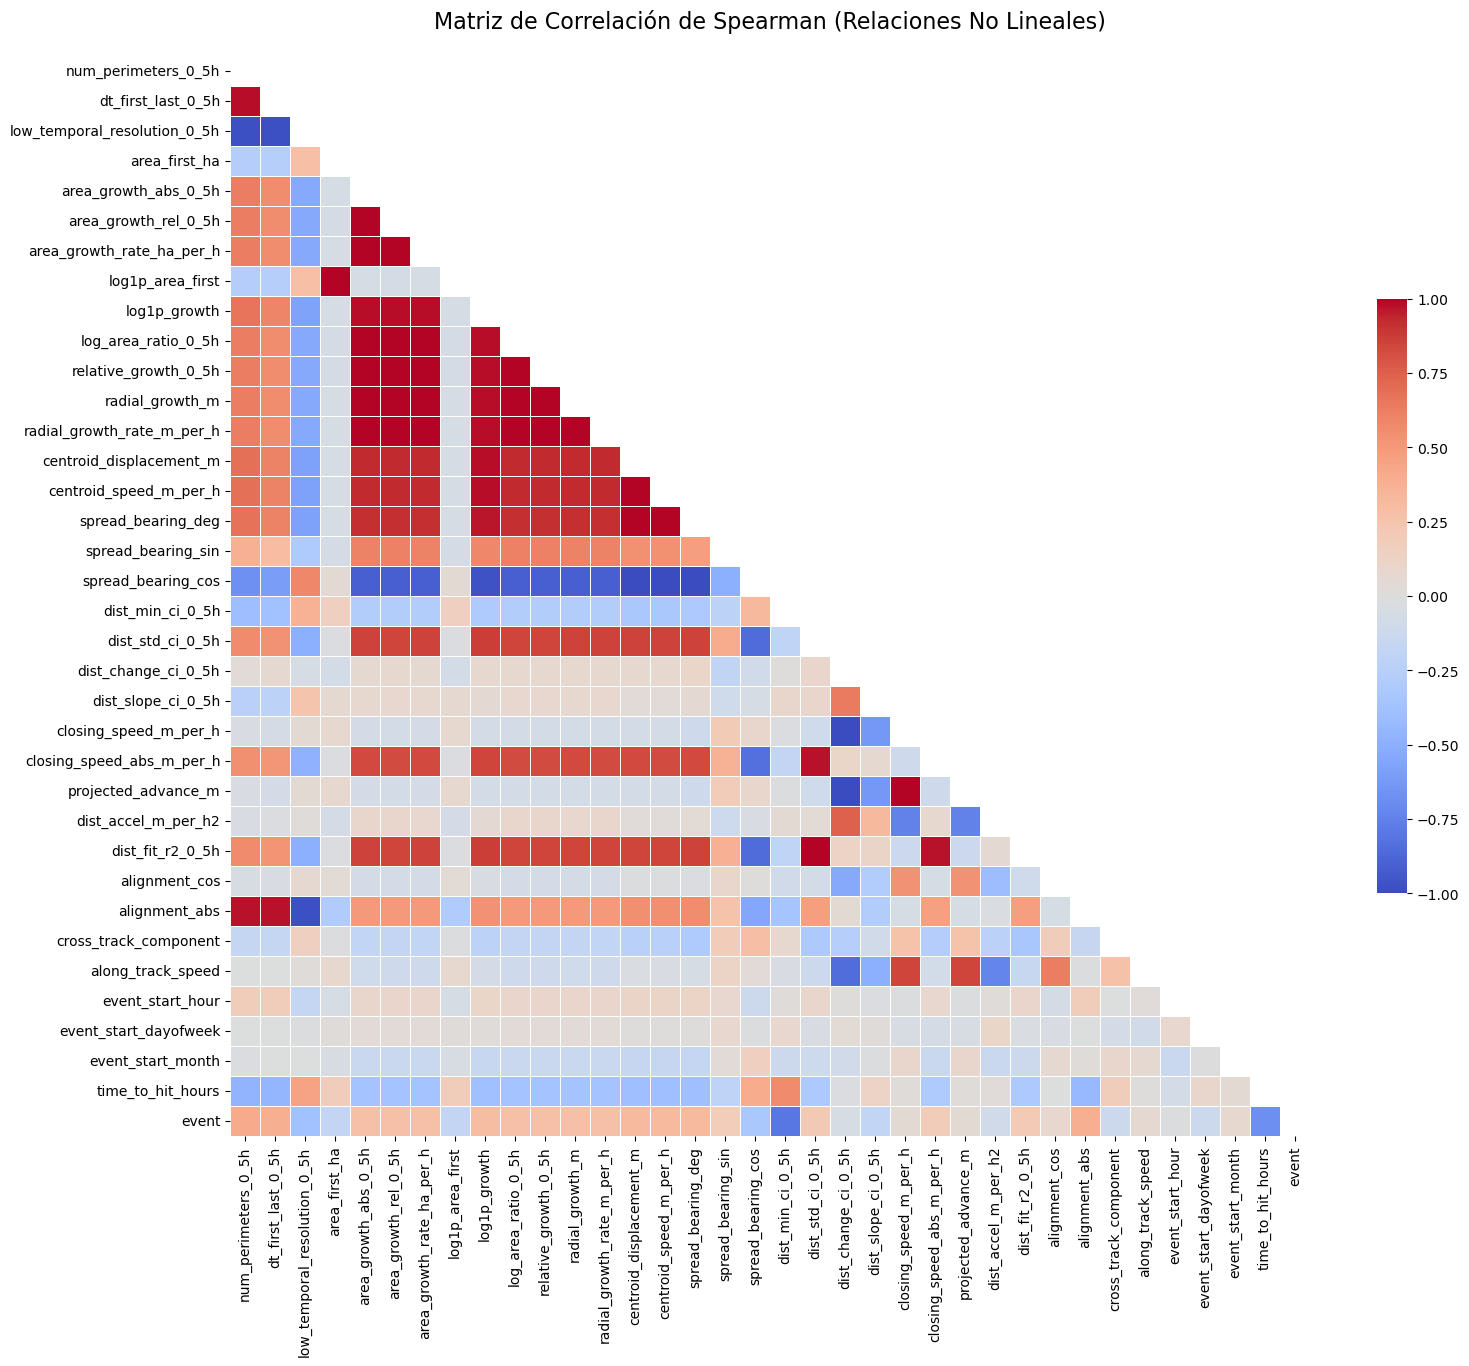

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Importamos numpy para hacer la "máscara"

# 1. Cargar los datos
print("Cargando datos...")
df_train = pd.read_csv('../data/train.csv')

# 2. Filtrar numéricas y quitar el identificador que no sirve para correlación
columnas_numericas = df_train.select_dtypes(include=['float64', 'int64'])
if 'event_id' in columnas_numericas.columns:
    columnas_numericas = columnas_numericas.drop(columns=['event_id'])

# 3. Calcular Correlación de Spearman
print("Calculando correlación de Spearman...")
corr_spearman = columnas_numericas.corr(method='spearman')

# 4. Ocultar (info duplicada)
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

# 5. Crear la visualización mejorada
plt.figure(figsize=(16, 14)) # La hicimos un poco más grande

sns.heatmap(corr_spearman, 
            mask=mask,        # Aplicamos la máscara
            annot=False,      
            cmap='coolwarm',  
            vmin=-1, vmax=1,
            square=True,      # Hace que las celdas sean cuadradas perfectas
            linewidths=.5,    # Agrega unas pequeñas líneas de separación
            cbar_kws={"shrink": .5}) # Hace la barra de color lateral más estética

plt.title('Matriz de Correlación de Spearman (Relaciones No Lineales)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

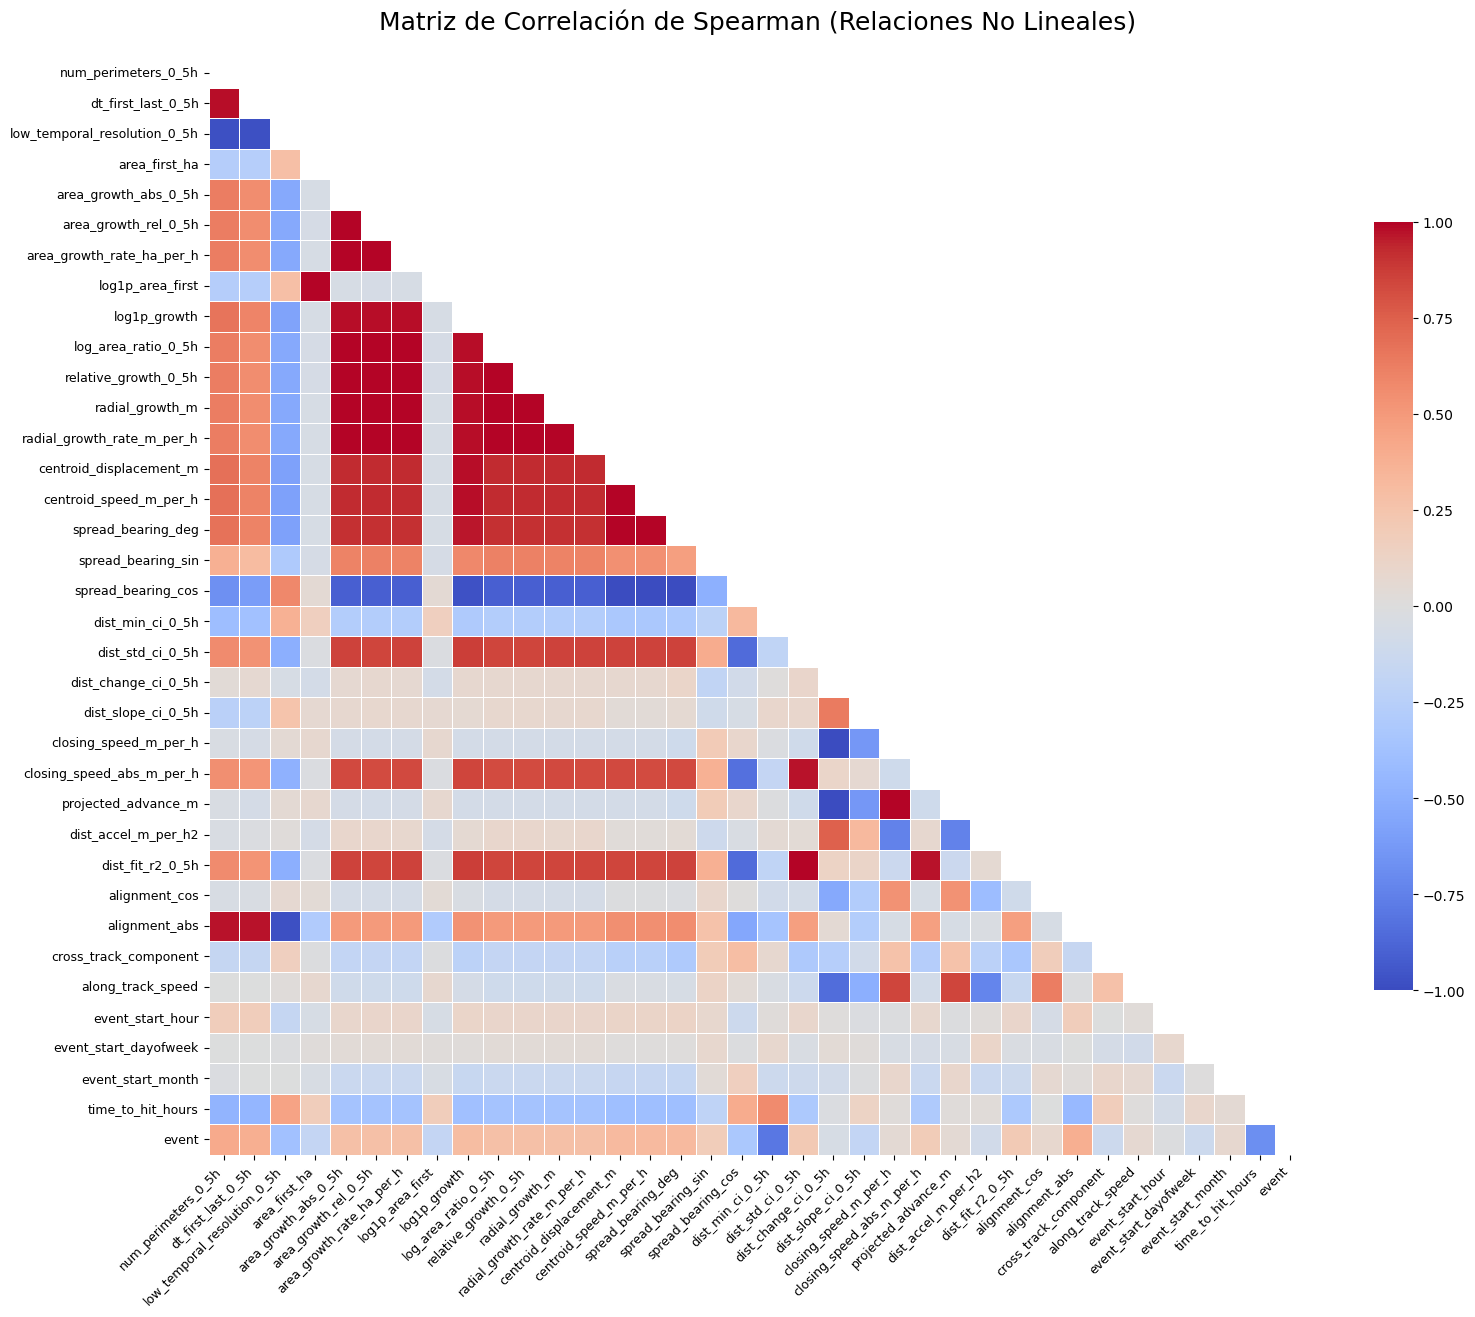

In [4]:
plt.figure(figsize=(16, 16))

sns.heatmap(corr_spearman, 
            mask=mask,        
            annot=False,      
            cmap='coolwarm',  
            vmin=-1, vmax=1,
            square=True,      
            linewidths=.5,    
            cbar_kws={"shrink": .5}) 


plt.xticks(rotation=45, ha='right', fontsize=9) # Rota el texto de abajo 45 grados
plt.yticks(fontsize=9) # Hace la letra un poco más pequeña para que no se encime


plt.title('Matriz de Correlación de Spearman (Relaciones No Lineales)', fontsize=18, pad=20)
plt.tight_layout() # Esto fuerza a que todos los textos entren en la imagen
plt.show()